#  Comprehensive Data Visualization & Market Analysis
**Project:** Algerian Laptop Market Analysis (Ouedkniss)
**Phase:** Exploratory Data Analysis (Phase 05)
**Objective:** Deep visual exploration of market patterns, trends, and relationships

---

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for professional-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load engineered dataset
df = pd.read_csv('../04_Feature_Engineering/engineered_dataset.csv')
print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Price range: {df['PRICE'].min():,.0f} - {df['PRICE'].max():,.0f} DZD")

 Dataset loaded: 48,669 rows × 22 columns
 Price range: 5,500 - 795,000 DZD


---
## 1 Price Distribution Analysis

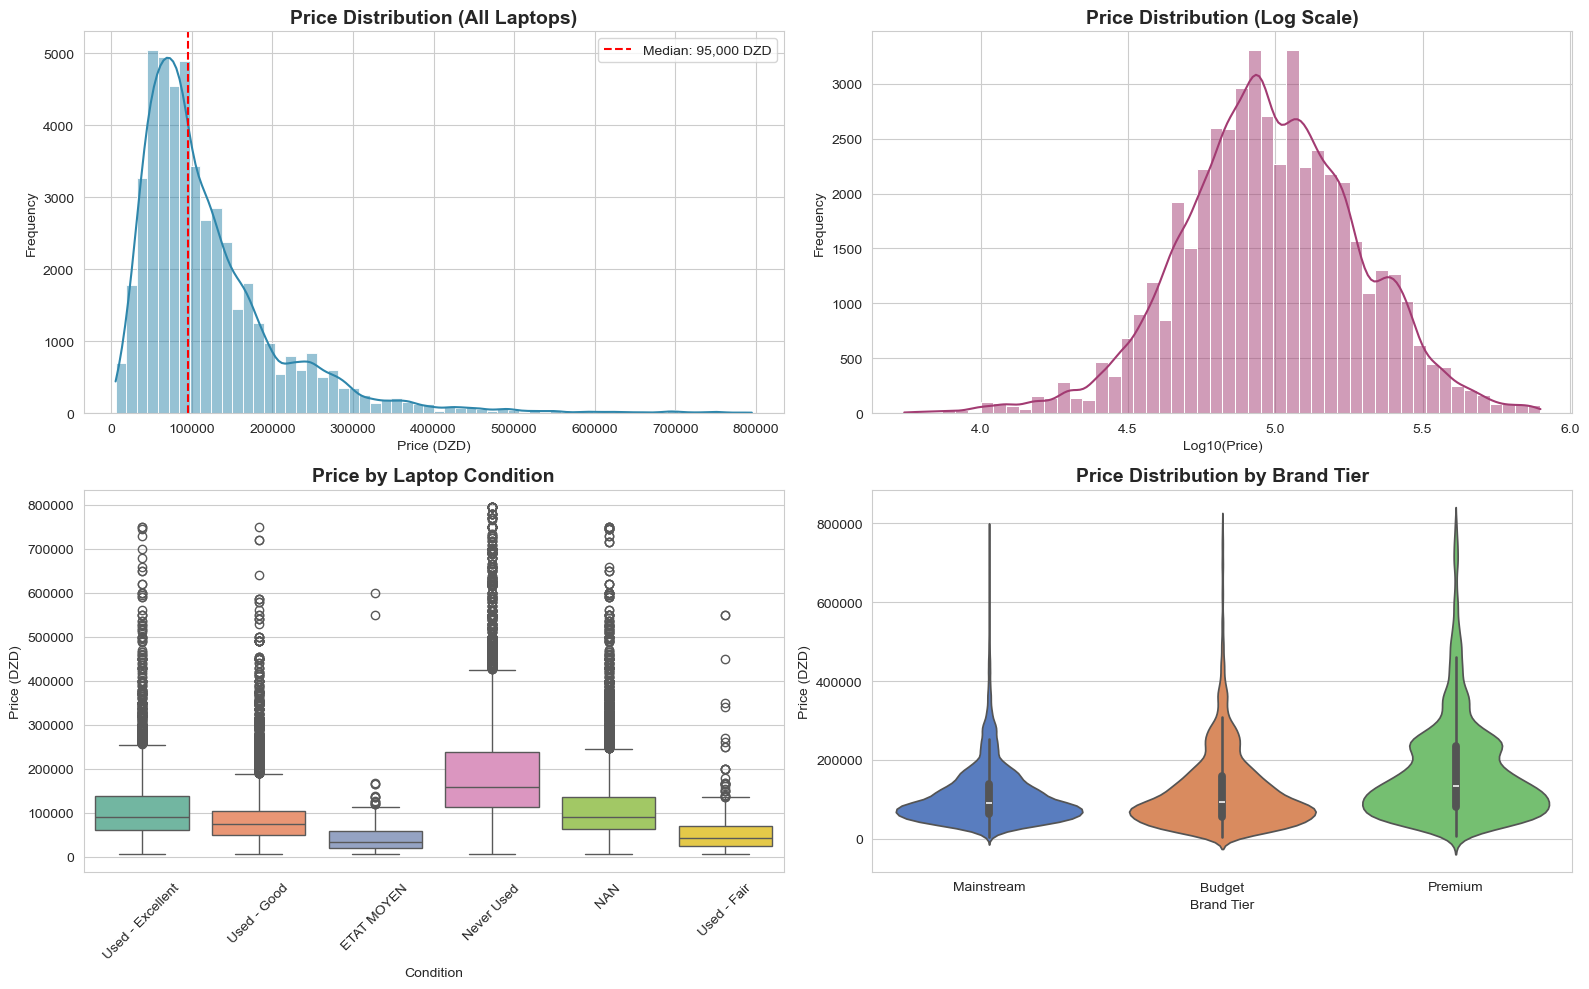


📈 Price Statistics:
count     48669.000000
mean     121649.411976
std       92741.301410
min        5500.000000
25%       62000.000000
50%       95000.000000
75%      150000.000000
max      795000.000000
Name: PRICE, dtype: float64


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Price Distribution with KDE
sns.histplot(df['PRICE'], bins=60, kde=True, color='#2E86AB', ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution (All Laptops)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price (DZD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['PRICE'].median(), color='red', linestyle='--', label=f'Median: {df["PRICE"].median():,.0f} DZD')
axes[0, 0].legend()

# 2. Log-scale Price Distribution
sns.histplot(np.log10(df['PRICE']), bins=50, kde=True, color='#A23B72', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log10(Price)')
axes[0, 1].set_ylabel('Frequency')

# 3. Box Plot by Condition
sns.boxplot(data=df, x='LAPTOP_CONDITION', y='PRICE', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Price by Laptop Condition', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Condition')
axes[1, 0].set_ylabel('Price (DZD)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Violin Plot by Brand Tier
sns.violinplot(data=df, x='BRAND_TIER', y='PRICE', palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution by Brand Tier', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Brand Tier')
axes[1, 1].set_ylabel('Price (DZD)')

plt.tight_layout()
plt.savefig('visualizations/01_price_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📈 Price Statistics:")
print(df['PRICE'].describe())

---
## 2 Brand Analysis

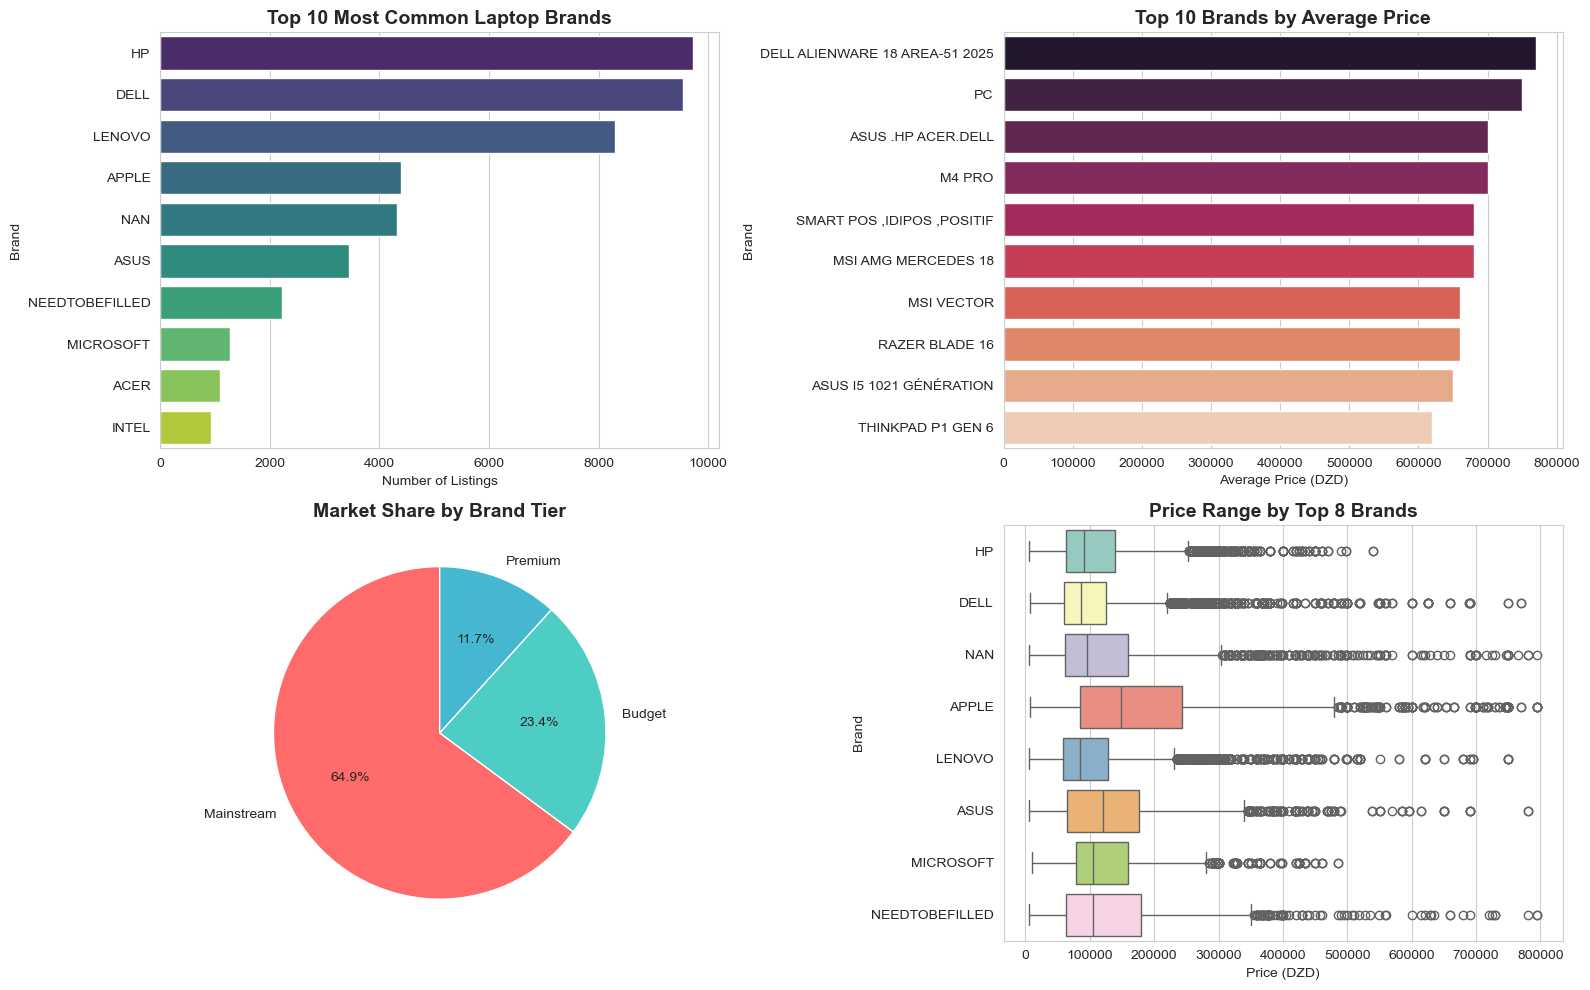

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top 10 Brands by Count
top_brands = df['LAPTOP_BRAND'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Most Common Laptop Brands', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Listings')
axes[0, 0].set_ylabel('Brand')

# 2. Average Price by Top Brands
brand_avg_price = df.groupby('LAPTOP_BRAND')['PRICE'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=brand_avg_price.values, y=brand_avg_price.index, palette='rocket', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Brands by Average Price', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Average Price (DZD)')
axes[0, 1].set_ylabel('Brand')

# 3. Brand Tier Distribution
brand_tier_counts = df['BRAND_TIER'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1, 0].pie(brand_tier_counts.values, labels=brand_tier_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[1, 0].set_title('Market Share by Brand Tier', fontsize=14, fontweight='bold')

# 4. Price Range by Brand (Top 8)
top_8_brands = df['LAPTOP_BRAND'].value_counts().head(8).index
df_top_brands = df[df['LAPTOP_BRAND'].isin(top_8_brands)]
sns.boxplot(data=df_top_brands, y='LAPTOP_BRAND', x='PRICE', palette='Set3', ax=axes[1, 1])
axes[1, 1].set_title('Price Range by Top 8 Brands', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Price (DZD)')
axes[1, 1].set_ylabel('Brand')

plt.tight_layout()
plt.savefig('visualizations/02_brand_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 3 Hardware Specifications Analysis

KeyError: 'STORAGE_TYPE'

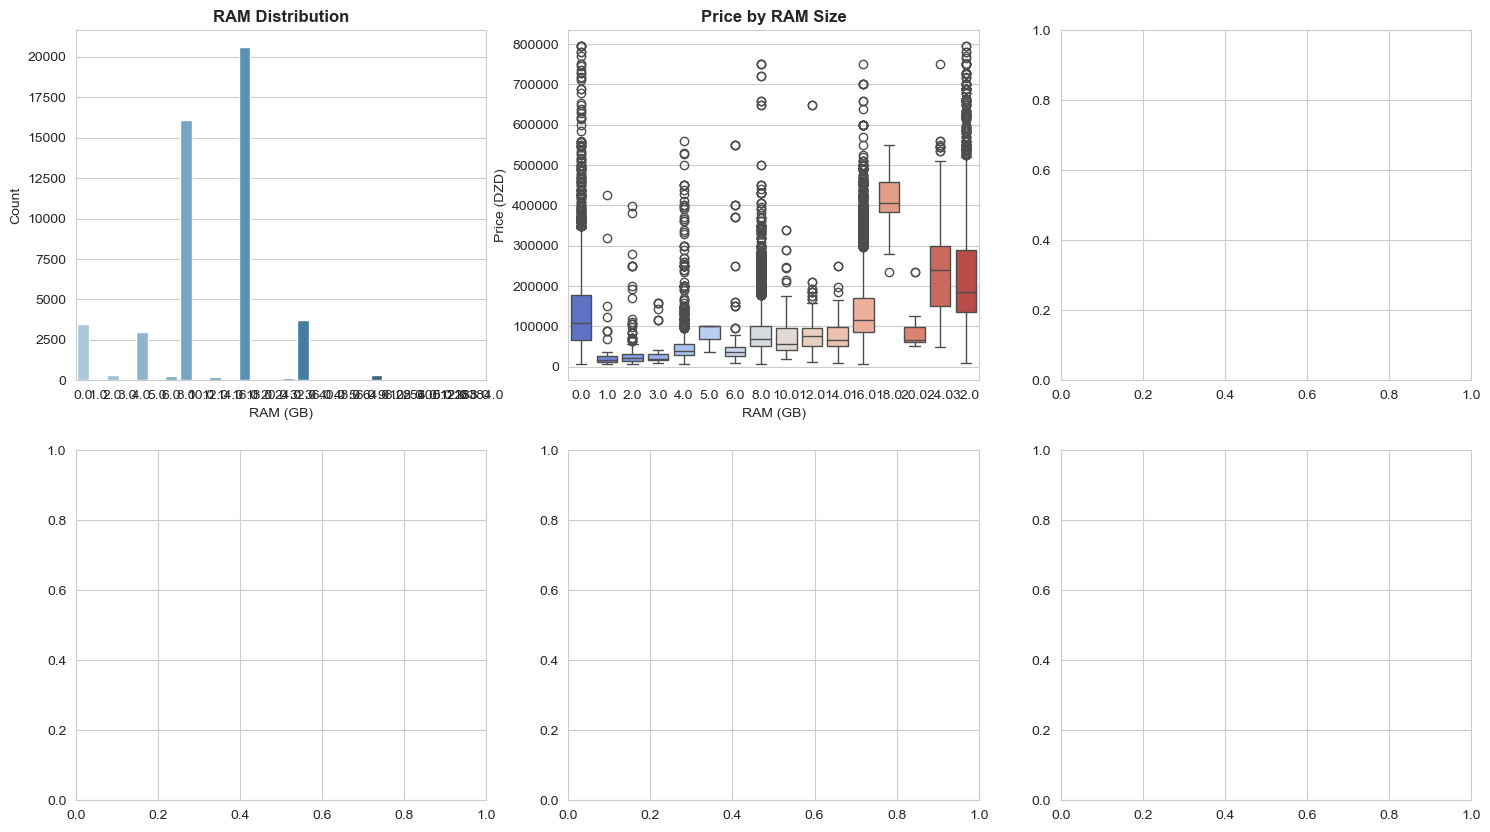

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. RAM Distribution
ram_counts = df['RAM_GB'].value_counts().sort_index()
sns.barplot(x=ram_counts.index, y=ram_counts.values, palette='Blues_d', ax=axes[0, 0])
axes[0, 0].set_title('RAM Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('RAM (GB)')
axes[0, 0].set_ylabel('Count')

# 2. Price vs RAM
sns.boxplot(data=df[df['RAM_GB'] <= 32], x='RAM_GB', y='PRICE', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Price by RAM Size', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('RAM (GB)')
axes[0, 1].set_ylabel('Price (DZD)')

# 3. Storage Type Distribution
storage_counts = df['STORAGE_TYPE'].value_counts()
axes[0, 2].pie(storage_counts.values, labels=storage_counts.index, autopct='%1.1f%%', 
               colors=['#95E1D3', '#F38181', '#EAFFD0'], startangle=45)
axes[0, 2].set_title('Storage Type Distribution', fontsize=12, fontweight='bold')

# 4. CPU Tier Distribution
cpu_counts = df['CPU_TIER'].value_counts()
sns.barplot(x=cpu_counts.index, y=cpu_counts.values, palette='Spectral', ax=axes[1, 0])
axes[1, 0].set_title('CPU Tier Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('CPU Tier')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Price by CPU Tier
sns.violinplot(data=df, x='CPU_TIER', y='PRICE', palette='pastel', ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution by CPU Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('CPU Tier')
axes[1, 1].set_ylabel('Price (DZD)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Price by Storage Type
sns.boxplot(data=df, x='STORAGE_TYPE', y='PRICE', palette='Set2', ax=axes[1, 2])
axes[1, 2].set_title('Price by Storage Type', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Storage Type')
axes[1, 2].set_ylabel('Price (DZD)')

plt.tight_layout()
plt.savefig('visualizations/03_hardware_specs_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 4 Gaming vs Office Laptops

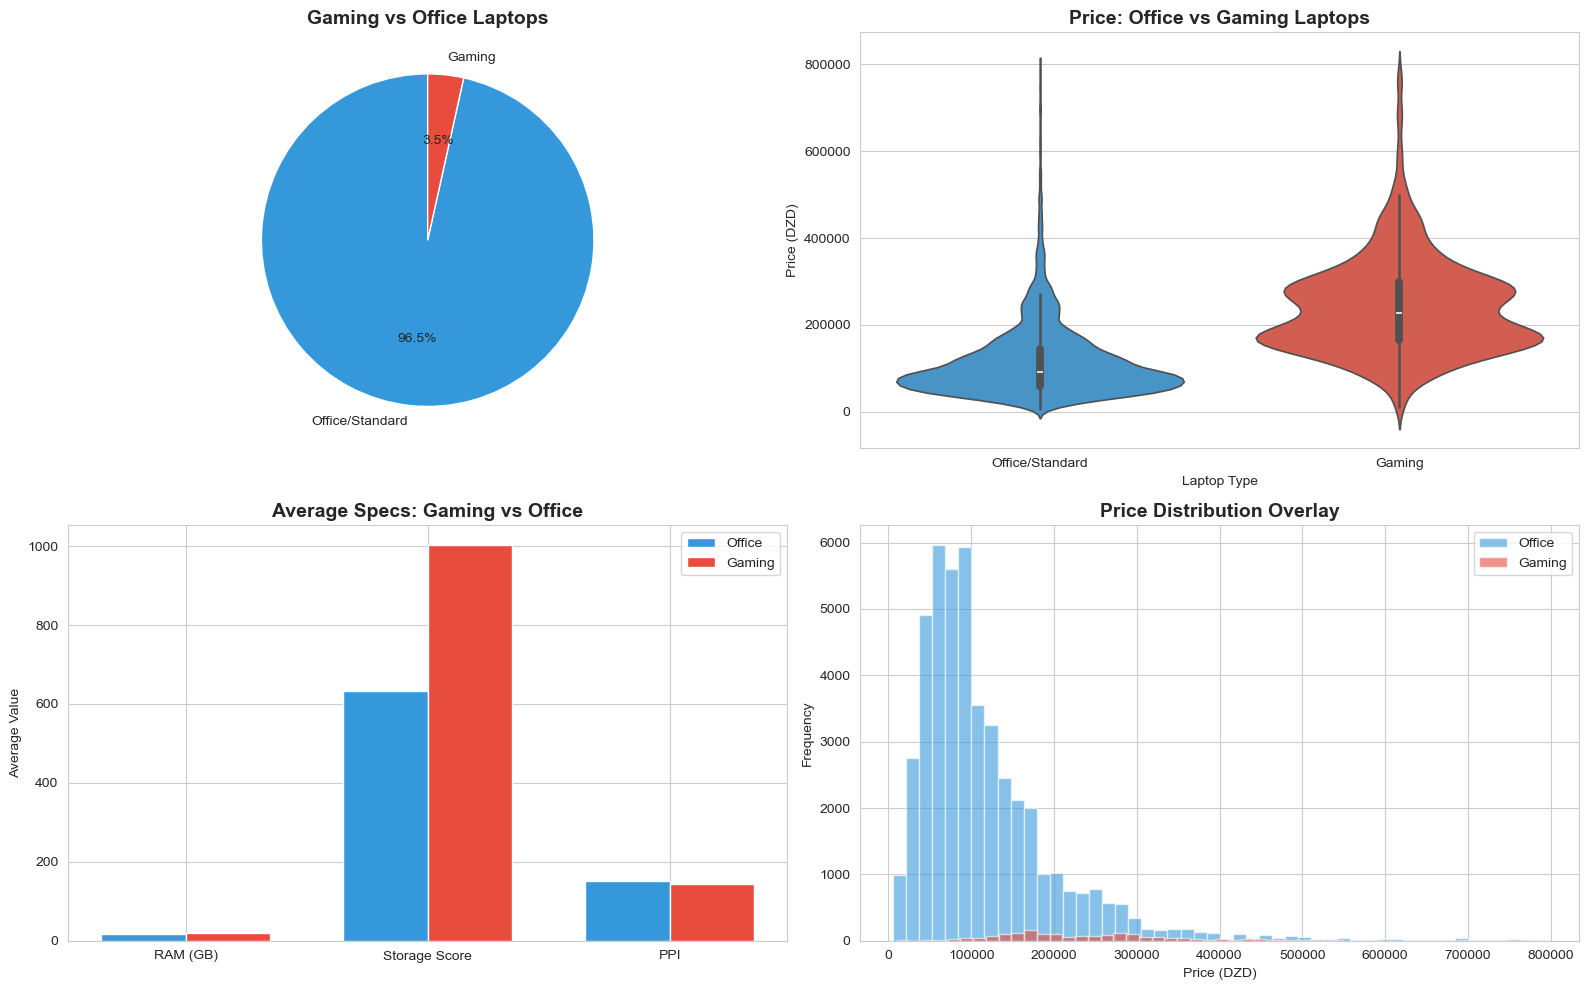


🎮 Gaming Laptops: 1,694 (3.5%)
💼 Office Laptops: 46,975 (96.5%)

💰 Average Price - Gaming: 241,455 DZD
💰 Average Price - Office: 117,329 DZD


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Gaming vs Office Count
gaming_counts = df['IS_GAMING'].value_counts()
labels = ['Office/Standard', 'Gaming']
colors = ['#3498db', '#e74c3c']
axes[0, 0].pie(gaming_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title('Gaming vs Office Laptops', fontsize=14, fontweight='bold')

# 2. Price Comparison
sns.violinplot(data=df, x='IS_GAMING', y='PRICE', palette=['#3498db', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title('Price: Office vs Gaming Laptops', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(['Office/Standard', 'Gaming'])
axes[0, 1].set_xlabel('Laptop Type')
axes[0, 1].set_ylabel('Price (DZD)')

# 3. Average Specs Comparison
gaming_avg = df[df['IS_GAMING'] == 1][['RAM_GB', 'STORAGE_SCORE', 'PPI']].mean()
office_avg = df[df['IS_GAMING'] == 0][['RAM_GB', 'STORAGE_SCORE', 'PPI']].mean()

x = np.arange(3)
width = 0.35
axes[1, 0].bar(x - width/2, office_avg.values, width, label='Office', color='#3498db')
axes[1, 0].bar(x + width/2, gaming_avg.values, width, label='Gaming', color='#e74c3c')
axes[1, 0].set_title('Average Specs: Gaming vs Office', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(['RAM (GB)', 'Storage Score', 'PPI'])
axes[1, 0].legend()
axes[1, 0].set_ylabel('Average Value')

# 4. Price Distribution Histogram
df[df['IS_GAMING'] == 0]['PRICE'].hist(bins=50, alpha=0.6, label='Office', color='#3498db', ax=axes[1, 1])
df[df['IS_GAMING'] == 1]['PRICE'].hist(bins=50, alpha=0.6, label='Gaming', color='#e74c3c', ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution Overlay', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Price (DZD)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('visualizations/04_gaming_vs_office.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Gaming Laptops: {gaming_counts[1]:,} ({gaming_counts[1]/len(df)*100:.1f}%)")
print(f" Office Laptops: {gaming_counts[0]:,} ({gaming_counts[0]/len(df)*100:.1f}%)")
print(f"\n Average Price - Gaming: {df[df['IS_GAMING']==1]['PRICE'].mean():,.0f} DZD")
print(f" Average Price - Office: {df[df['IS_GAMING']==0]['PRICE'].mean():,.0f} DZD")

---
## 5 Screen & Display Analysis

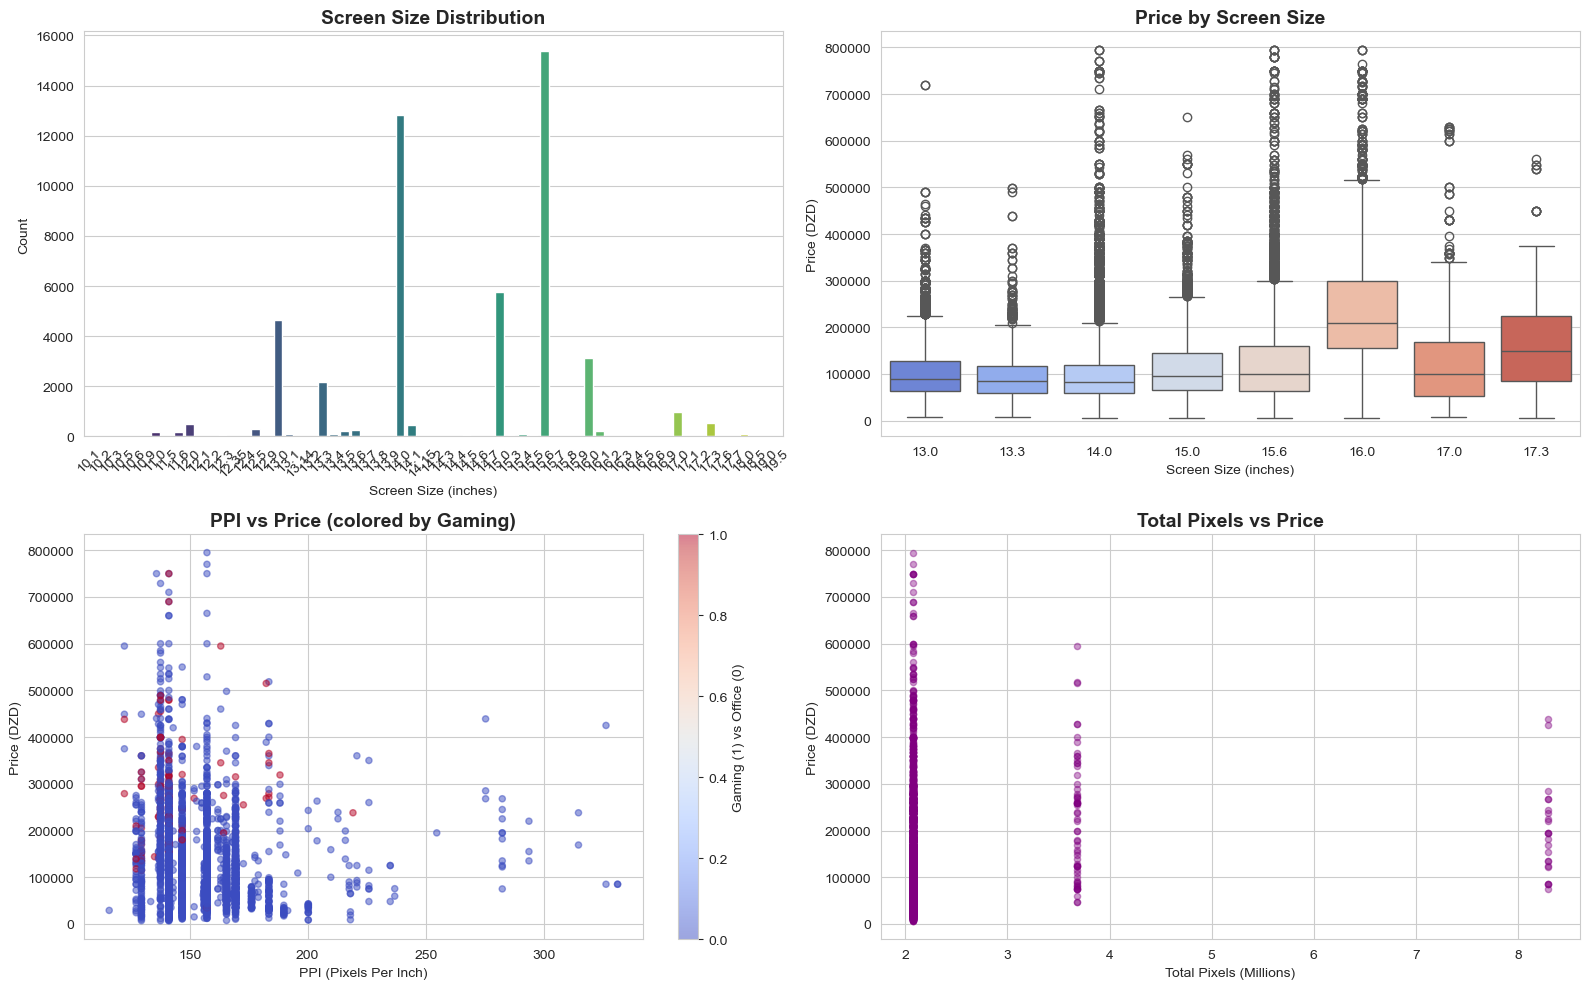

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Screen Size Distribution
screen_counts = df['SCREEN_SIZE'].value_counts().sort_index()
sns.barplot(x=screen_counts.index, y=screen_counts.values, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Screen Size Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Screen Size (inches)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Price vs Screen Size
common_sizes = df['SCREEN_SIZE'].value_counts().head(8).index
df_common_sizes = df[df['SCREEN_SIZE'].isin(common_sizes)]
sns.boxplot(data=df_common_sizes, x='SCREEN_SIZE', y='PRICE', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Price by Screen Size', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Screen Size (inches)')
axes[0, 1].set_ylabel('Price (DZD)')

# 3. PPI vs Price Scatter
sample = df.sample(min(5000, len(df)))  # Sample for performance
scatter = axes[1, 0].scatter(sample['PPI'], sample['PRICE'], 
                            c=sample['IS_GAMING'], cmap='coolwarm', alpha=0.5, s=20)
axes[1, 0].set_title('PPI vs Price (colored by Gaming)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('PPI (Pixels Per Inch)')
axes[1, 0].set_ylabel('Price (DZD)')
plt.colorbar(scatter, ax=axes[1, 0], label='Gaming (1) vs Office (0)')

# 4. Total Pixels vs Price
axes[1, 1].scatter(sample['TOTAL_PIXELS']/1e6, sample['PRICE'], alpha=0.4, c='purple', s=20)
axes[1, 1].set_title('Total Pixels vs Price', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Total Pixels (Millions)')
axes[1, 1].set_ylabel('Price (DZD)')

plt.tight_layout()
plt.savefig('visualizations/05_screen_display_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 6 Correlation Analysis

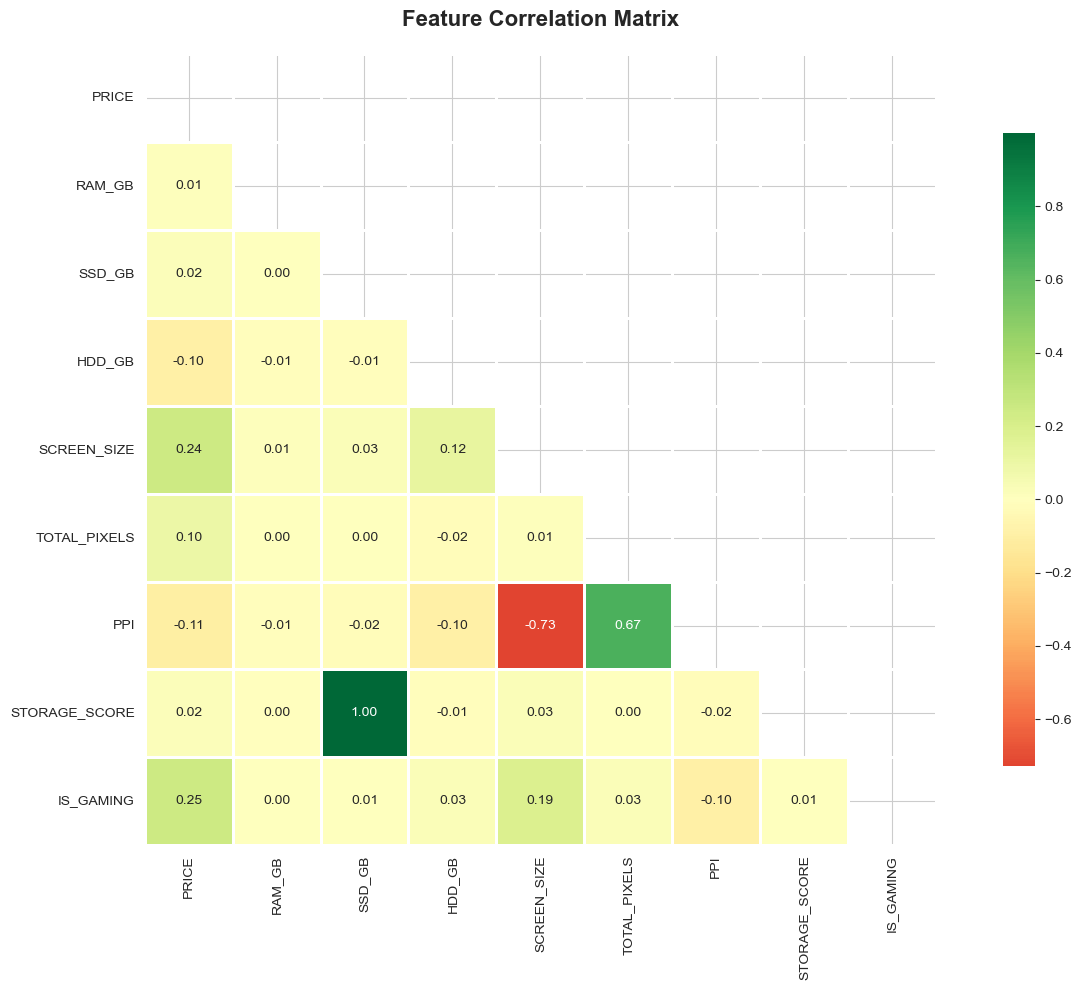


 Features Most Correlated with PRICE:
PRICE            1.000000
IS_GAMING        0.245320
SCREEN_SIZE      0.244046
TOTAL_PIXELS     0.098194
SSD_GB           0.017560
STORAGE_SCORE    0.017219
RAM_GB           0.012348
HDD_GB          -0.096028
PPI             -0.106563
Name: PRICE, dtype: float64


In [7]:
# Select numerical features for correlation
numerical_features = ['PRICE', 'RAM_GB', 'SSD_GB', 'HDD_GB', 'SCREEN_SIZE', 
                     'TOTAL_PIXELS', 'PPI', 'STORAGE_SCORE', 'IS_GAMING']

# Filter features that exist in the dataset
available_features = [f for f in numerical_features if f in df.columns]
corr_matrix = df[available_features].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with PRICE
price_corr = corr_matrix['PRICE'].sort_values(ascending=False)
print("\n Features Most Correlated with PRICE:")
print(price_corr)

---
## 7 Temporal Analysis (Posting Trends)

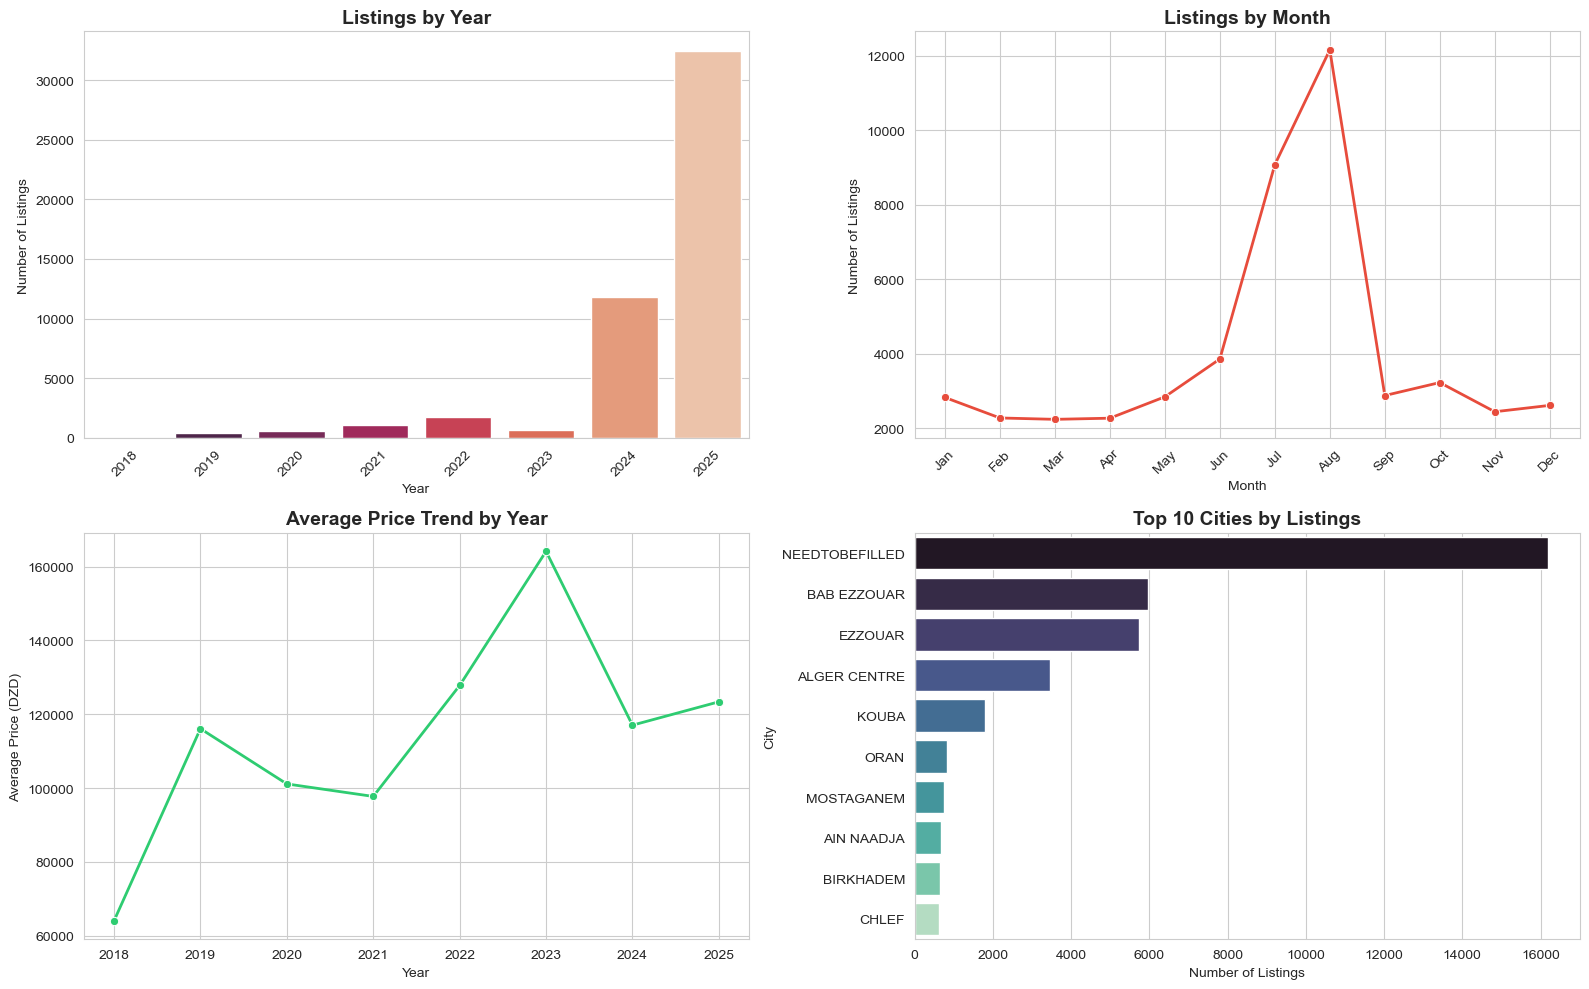

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Listings by Year
if 'POST_YEAR' in df.columns:
    year_counts = df['POST_YEAR'].value_counts().sort_index()
    sns.barplot(x=year_counts.index, y=year_counts.values, palette='rocket', ax=axes[0, 0])
    axes[0, 0].set_title('Listings by Year', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Number of Listings')
    axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Listings by Month
if 'POST_MONTH' in df.columns:
    month_counts = df['POST_MONTH'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o', 
                color='#e74c3c', linewidth=2, ax=axes[0, 1])
    axes[0, 1].set_title('Listings by Month', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Number of Listings')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(month_names, rotation=45)

# 3. Average Price by Year
if 'POST_YEAR' in df.columns:
    year_avg_price = df.groupby('POST_YEAR')['PRICE'].mean()
    sns.lineplot(x=year_avg_price.index, y=year_avg_price.values, 
                marker='o', color='#2ecc71', linewidth=2, ax=axes[1, 0])
    axes[1, 0].set_title('Average Price Trend by Year', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Average Price (DZD)')

# 4. City Distribution (Top 10)
if 'CITY' in df.columns:
    city_counts = df['CITY'].value_counts().head(10)
    sns.barplot(y=city_counts.index, x=city_counts.values, palette='mako', ax=axes[1, 1])
    axes[1, 1].set_title('Top 10 Cities by Listings', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Listings')
    axes[1, 1].set_ylabel('City')

plt.tight_layout()
plt.savefig('visualizations/07_temporal_geographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 8 Advanced Feature Relationships

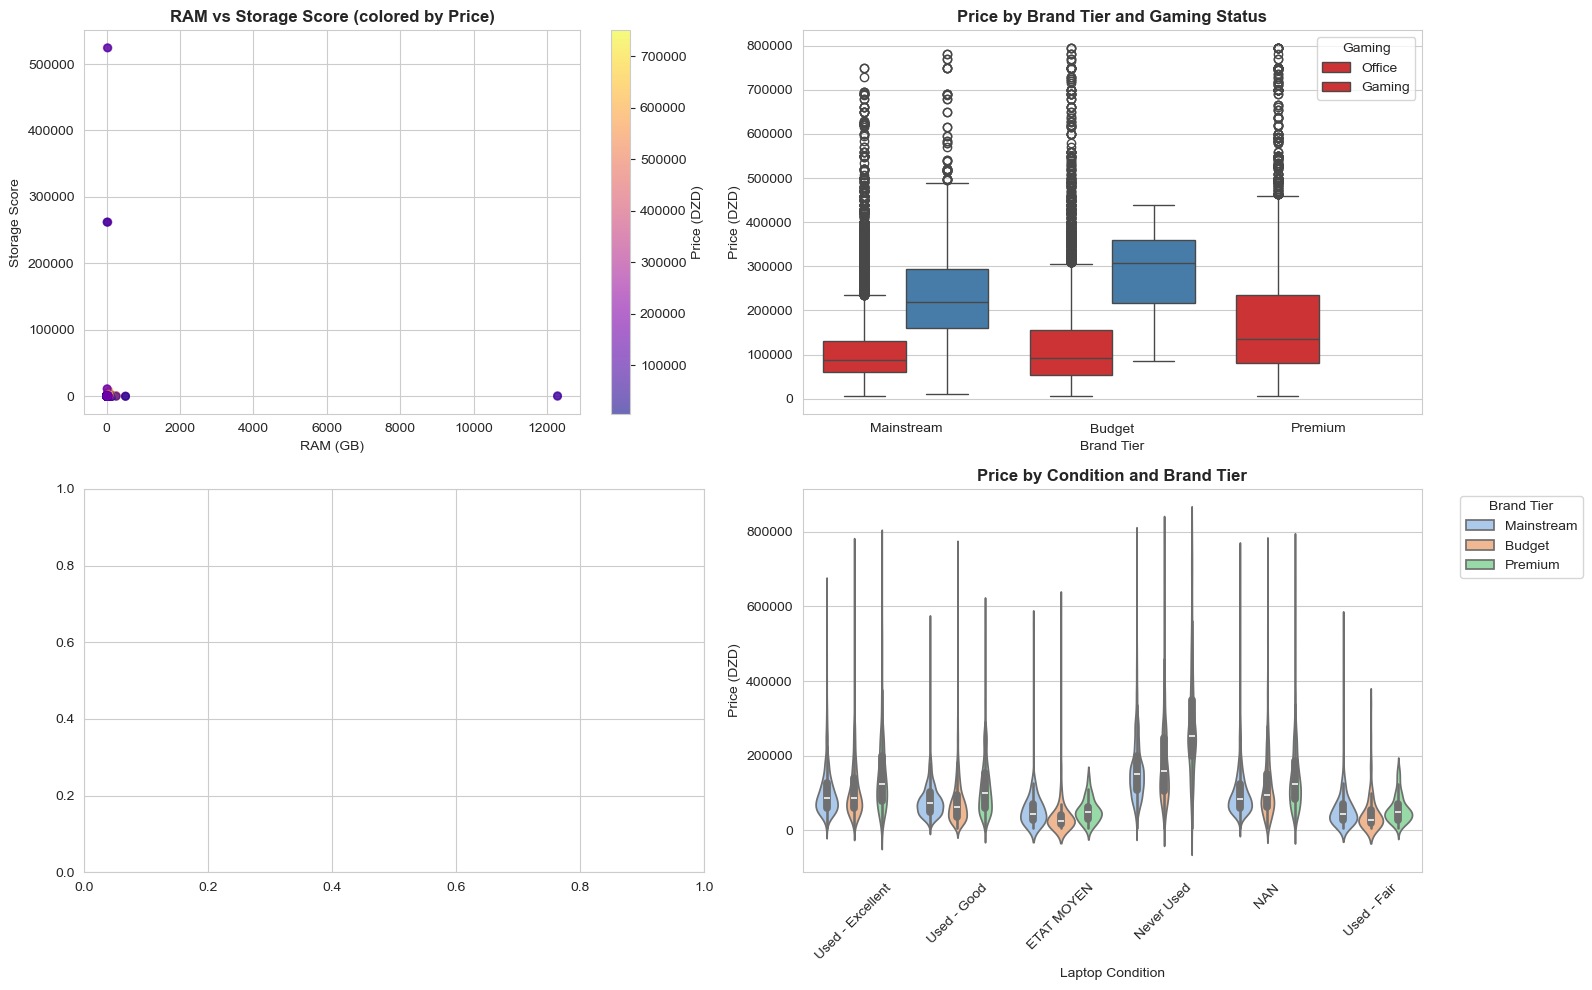

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. RAM vs Storage Score (colored by price)
sample = df.sample(min(3000, len(df)))
scatter = axes[0, 0].scatter(sample['RAM_GB'], sample['STORAGE_SCORE'], 
                            c=sample['PRICE'], cmap='plasma', alpha=0.6, s=30)
axes[0, 0].set_title('RAM vs Storage Score (colored by Price)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('RAM (GB)')
axes[0, 0].set_ylabel('Storage Score')
plt.colorbar(scatter, ax=axes[0, 0], label='Price (DZD)')

# 2. Price by Brand Tier and Gaming
sns.boxplot(data=df, x='BRAND_TIER', y='PRICE', hue='IS_GAMING', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Price by Brand Tier and Gaming Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Brand Tier')
axes[0, 1].set_ylabel('Price (DZD)')
axes[0, 1].legend(title='Gaming', labels=['Office', 'Gaming'])

# 3. Storage Type vs CPU Tier Heatmap
if 'CPU_TIER' in df.columns and 'STORAGE_TYPE' in df.columns:
    cross_tab = pd.crosstab(df['CPU_TIER'], df['STORAGE_TYPE'])
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
    axes[1, 0].set_title('CPU Tier vs Storage Type Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Storage Type')
    axes[1, 0].set_ylabel('CPU Tier')

# 4. Price Distribution by Condition and Brand Tier
sns.violinplot(data=df, x='LAPTOP_CONDITION', y='PRICE', hue='BRAND_TIER', 
              split=False, palette='pastel', ax=axes[1, 1])
axes[1, 1].set_title('Price by Condition and Brand Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Laptop Condition')
axes[1, 1].set_ylabel('Price (DZD)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Brand Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('visualizations/08_advanced_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 9 Market Segmentation Preview

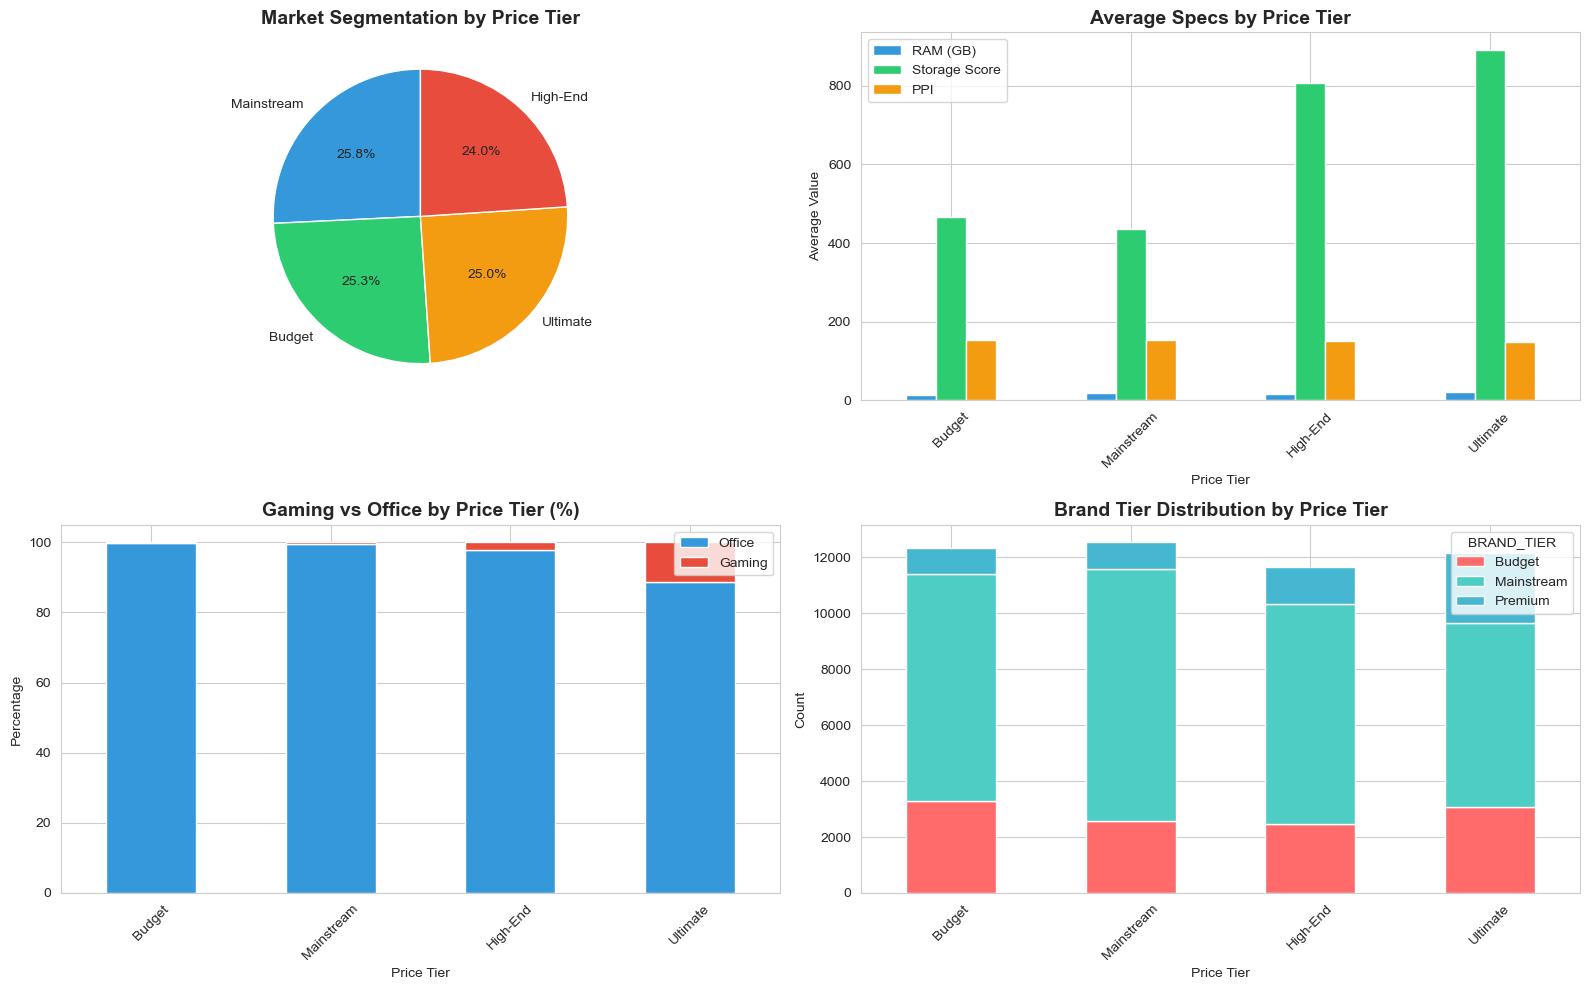


 Price Tier Boundaries:
Budget: 5,500 - 62,000 DZD (avg: 43,163)
Mainstream: 62,500 - 95,000 DZD (avg: 78,887)
High-End: 95,500 - 150,000 DZD (avg: 121,352)
Ultimate: 151,000 - 795,000 DZD (avg: 245,589)


In [10]:
# Create price tiers for visualization
df['PRICE_TIER'] = pd.qcut(df['PRICE'], q=4, labels=['Budget', 'Mainstream', 'High-End', 'Ultimate'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Price Tier Distribution
tier_counts = df['PRICE_TIER'].value_counts()
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
axes[0, 0].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%', 
              colors=colors, startangle=90)
axes[0, 0].set_title('Market Segmentation by Price Tier', fontsize=14, fontweight='bold')

# 2. Average Specs by Price Tier
tier_specs = df.groupby('PRICE_TIER')[['RAM_GB', 'STORAGE_SCORE', 'PPI']].mean()
tier_specs.plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#2ecc71', '#f39c12'])
axes[0, 1].set_title('Average Specs by Price Tier', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price Tier')
axes[0, 1].set_ylabel('Average Value')
axes[0, 1].legend(['RAM (GB)', 'Storage Score', 'PPI'])
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Gaming Distribution by Price Tier
gaming_by_tier = pd.crosstab(df['PRICE_TIER'], df['IS_GAMING'], normalize='index') * 100
gaming_by_tier.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                   color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Gaming vs Office by Price Tier (%)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Price Tier')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].legend(['Office', 'Gaming'])
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Brand Tier Distribution by Price Tier
brand_by_price = pd.crosstab(df['PRICE_TIER'], df['BRAND_TIER'])
brand_by_price.plot(kind='bar', stacked=True, ax=axes[1, 1], 
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 1].set_title('Brand Tier Distribution by Price Tier', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Price Tier')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('visualizations/09_market_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

# Print tier statistics
print("\n Price Tier Boundaries:")
for tier in ['Budget', 'Mainstream', 'High-End', 'Ultimate']:
    tier_data = df[df['PRICE_TIER'] == tier]['PRICE']
    print(f"{tier}: {tier_data.min():,.0f} - {tier_data.max():,.0f} DZD (avg: {tier_data.mean():,.0f})")

---
## 10 Summary Statistics Dashboard

In [12]:
print("="*80)
print(" COMPREHENSIVE MARKET ANALYSIS SUMMARY")
print("="*80)

print(f"\n Dataset Overview:")
print(f"   Total Listings: {len(df):,}")
print(f"   Features: {df.shape[1]}")
print(f"   Date Range: {df['POST_YEAR'].min():.0f} - {df['POST_YEAR'].max():.0f}" if 'POST_YEAR' in df.columns else "")

print(f"\n Price Statistics:")
print(f"   Minimum: {df['PRICE'].min():,.0f} DZD")
print(f"   Maximum: {df['PRICE'].max():,.0f} DZD")
print(f"   Mean: {df['PRICE'].mean():,.0f} DZD")
print(f"   Median: {df['PRICE'].median():,.0f} DZD")
print(f"   Std Dev: {df['PRICE'].std():,.0f} DZD")

print(f"\n Brand Analysis:")
print(f"   Total Brands: {df['LAPTOP_BRAND'].nunique()}")
print(f"   Most Common: {df['LAPTOP_BRAND'].mode()[0]} ({df['LAPTOP_BRAND'].value_counts().iloc[0]:,} listings)")
print(f"   Premium Brands: {(df['BRAND_TIER']=='Premium').sum():,} ({(df['BRAND_TIER']=='Premium').sum()/len(df)*100:.1f}%)")

print(f"\n Hardware Statistics:")
print(f"   Average RAM: {df['RAM_GB'].mean():.1f} GB")
print(f"   SSD Laptops: {(df['SSD_GB'] > 0).sum():,} ({(df['SSD_GB'] > 0).sum()/len(df)*100:.1f}%)")
print(f"   Gaming Laptops: {(df['IS_GAMING']==1).sum():,} ({(df['IS_GAMING']==1).sum()/len(df)*100:.1f}%)")

print(f"\n Gaming Premium:")
gaming_premium = df[df['IS_GAMING']==1]['PRICE'].mean() - df[df['IS_GAMING']==0]['PRICE'].mean()
print(f"   Gaming laptops cost {gaming_premium:,.0f} DZD more on average")
print(f"   That's a {gaming_premium/df[df['IS_GAMING']==0]['PRICE'].mean()*100:.1f}% premium!")

print(f"\n All visualizations saved to: visualizations/")
print("="*80)

 COMPREHENSIVE MARKET ANALYSIS SUMMARY

 Dataset Overview:
   Total Listings: 48,669
   Features: 23
   Date Range: 2018 - 2025

 Price Statistics:
   Minimum: 5,500 DZD
   Maximum: 795,000 DZD
   Mean: 121,649 DZD
   Median: 95,000 DZD
   Std Dev: 92,741 DZD

 Brand Analysis:
   Total Brands: 936
   Most Common: HP (9,715 listings)
   Premium Brands: 5,700 (11.7%)

 Hardware Statistics:
   Average RAM: 18.2 GB
   SSD Laptops: 42,098 (86.5%)
   Gaming Laptops: 1,694 (3.5%)

 Gaming Premium:
   Gaming laptops cost 124,126 DZD more on average
   That's a 105.8% premium!

 All visualizations saved to: visualizations/
